In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
df = sns.load_dataset("titanic")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print(df.info())
print("\nMissing values:\n")
print(df.isnull().sum())

print("\nSummary statistics:\n")
display(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Missing values:

survived         0
pclass           0
sex              0

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df = df[[
    "survived", "pclass", "sex", "age", "sibsp", "parch",
    "fare", "embarked", "class", "who", "alone"
]]

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True


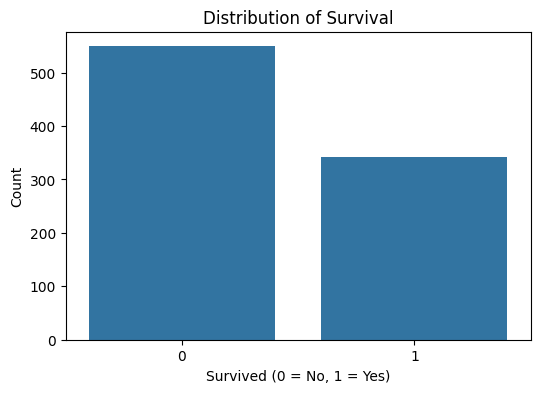

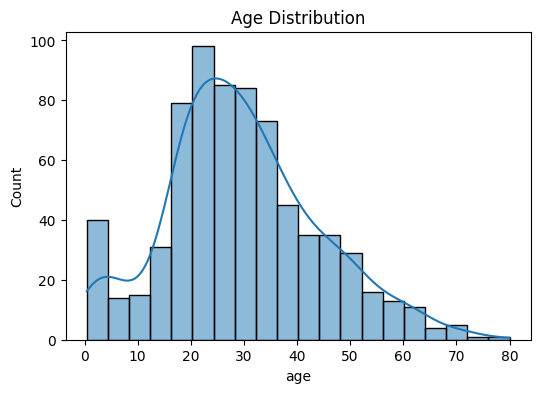

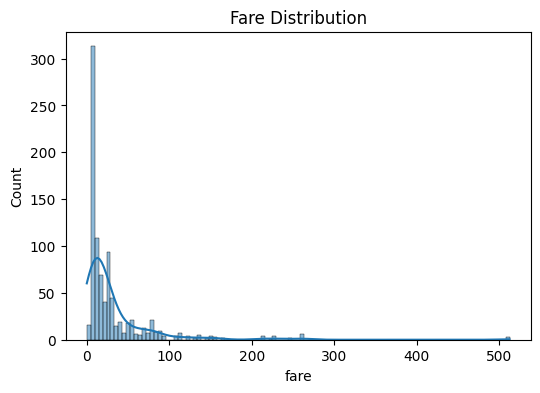

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="survived")
plt.title("Distribution of Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data=df, x="age", kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data=df, x="fare", kde=True)
plt.title("Fare Distribution")
plt.show()

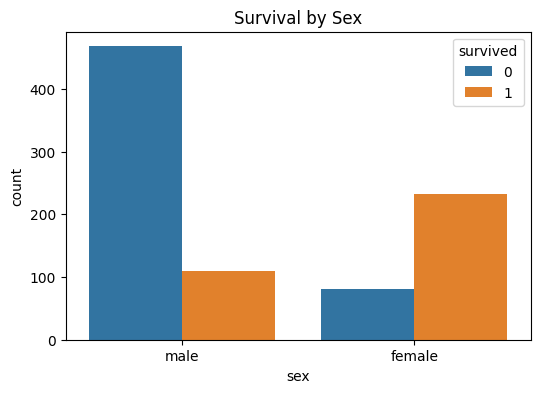

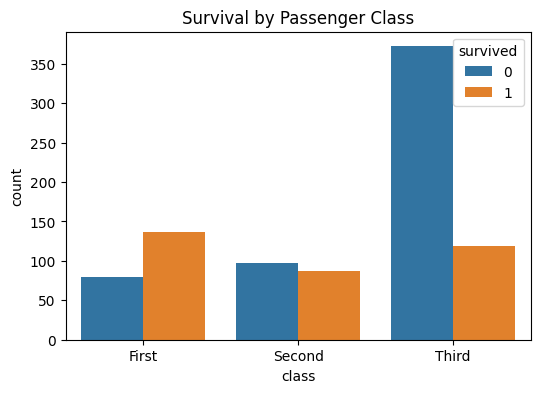

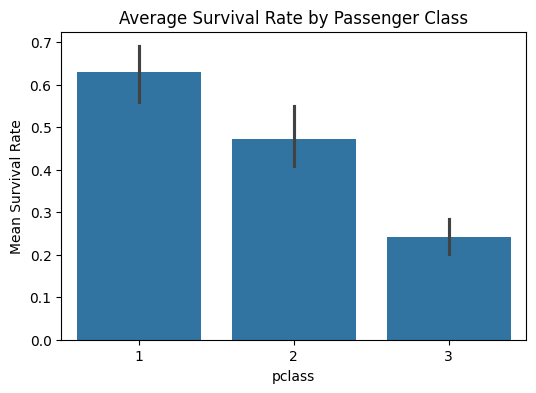

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Survival by Sex")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="class", hue="survived")
plt.title("Survival by Passenger Class")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="pclass", y="survived")
plt.title("Average Survival Rate by Passenger Class")
plt.ylabel("Mean Survival Rate")
plt.show()

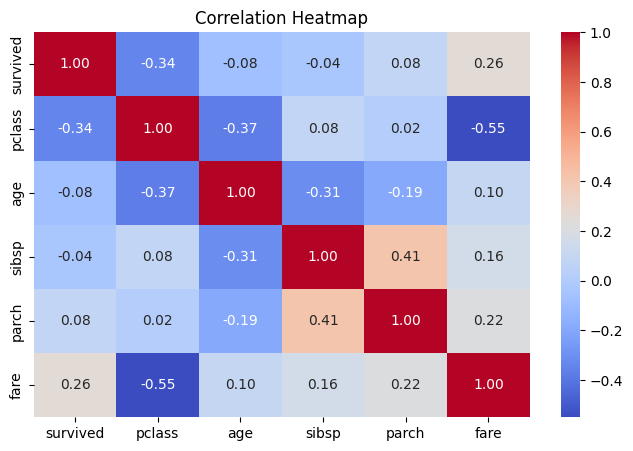

In [7]:
numeric_df = df[["survived", "pclass", "age", "sibsp", "parch", "fare"]]

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [8]:
df["family_size"] = df["sibsp"] + df["parch"] + 1
df["is_child"] = (df["age"] < 16).astype(int)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,alone,family_size,is_child
0,0,3,male,22.0,1,0,7.2500,S,Third,man,False,2,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,2,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,True,1,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,2,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,1,0


In [9]:
X = df.drop("survived", axis=1)
y = df["survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 12)
y shape: (891,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


In [12]:
numeric_features = ["age", "sibsp", "parch", "fare", "family_size", "is_child", "pclass"]
categorical_features = ["sex", "embarked", "class", "who", "alone"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [13]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sibsp', 'parch',
                                                   'fare', 'family_size',
                                                   'is_child', 'pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked', 'class',
                                                   'who', 'alone'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [14]:
y_pred = log_reg_pipeline.predict(X_test)
y_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

In [15]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

Accuracy:  0.8324
Precision: 0.8095
Recall:    0.7391
F1-score:  0.7727
ROC-AUC:   0.8690


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87       110
           1       0.81      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



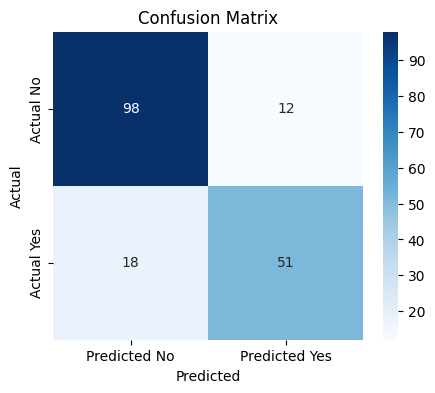

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted No", "Predicted Yes"],
            yticklabels=["Actual No", "Actual Yes"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

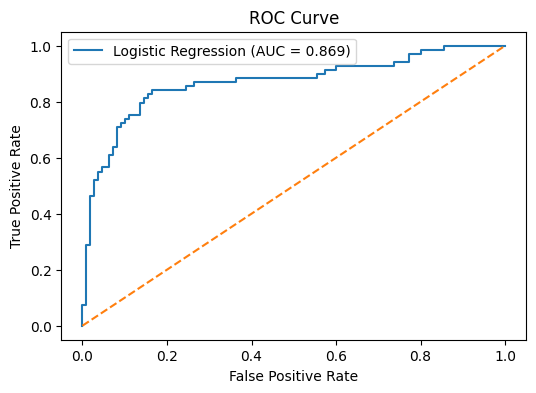

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [19]:
cv_scores = cross_val_score(log_reg_pipeline, X, y, cv=5, scoring="accuracy")

print("Cross-validation accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation accuracy scores: [0.82122905 0.79775281 0.80337079 0.80337079 0.85955056]
Mean CV accuracy: 0.8170547988199107
Standard deviation: 0.0226732681507431


In [20]:
tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=4, random_state=42))
])

tree_pipeline.fit(X_train, y_train)
tree_pred = tree_pipeline.predict(X_test)
tree_prob = tree_pipeline.predict_proba(X_test)[:, 1]

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print("Decision Tree F1-score:", f1_score(y_test, tree_pred))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, tree_prob))

Decision Tree Accuracy: 0.8324022346368715
Decision Tree F1-score: 0.7761194029850746
Decision Tree ROC-AUC: 0.8723978919631095


In [21]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, tree_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, tree_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, tree_pred)
    ],
    "F1-score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, tree_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, tree_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.832402,0.809524,0.739130,0.772727,0.869038
1,Decision Tree,0.832402,0.800000,0.753623,0.776119,0.872398


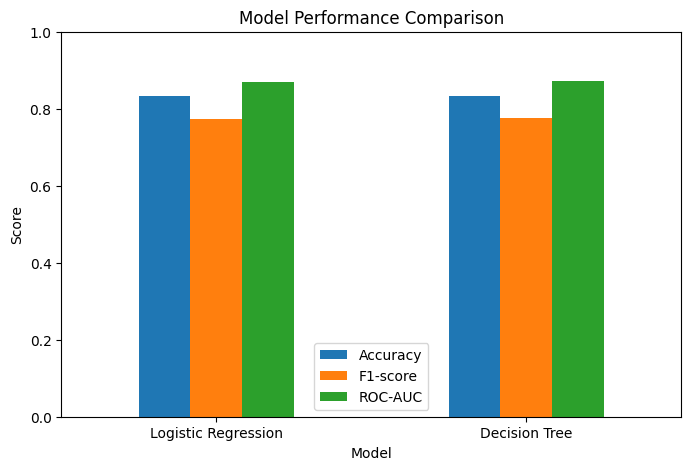

In [22]:
results.set_index("Model")[["Accuracy", "F1-score", "ROC-AUC"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

In [23]:
feature_names = log_reg_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = log_reg_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient
17,cat__who_woman,1.163870
5,num__is_child,0.351824
10,cat__embarked_Q,0.282166
7,cat__sex_female,0.281159
18,cat__alone_False,0.267938
12,cat__class_First,0.264380
3,num__fare,0.120818
15,cat__who_child,0.104823
9,cat__embarked_C,0.032897
13,cat__class_Second,0.020603


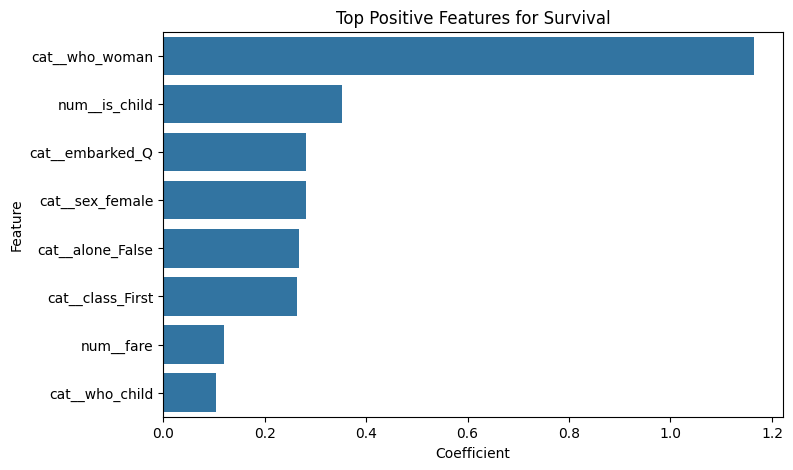

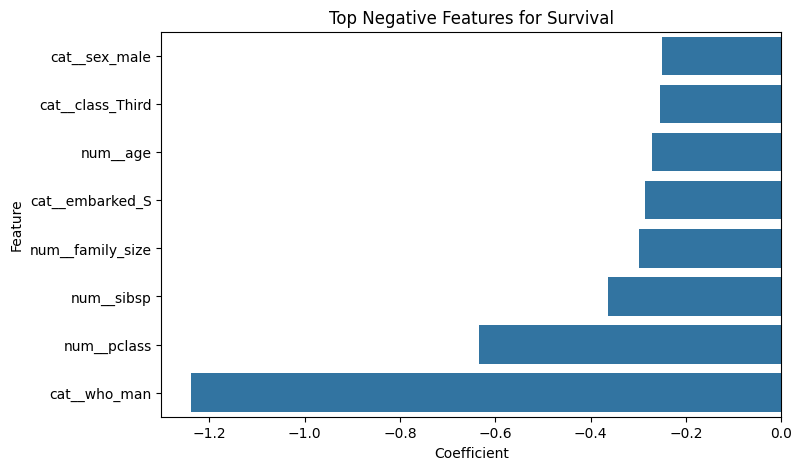

In [24]:
top_positive = coef_df.head(8)
top_negative = coef_df.tail(8)

plt.figure(figsize=(8,5))
sns.barplot(data=top_positive, x="Coefficient", y="Feature")
plt.title("Top Positive Features for Survival")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=top_negative, x="Coefficient", y="Feature")
plt.title("Top Negative Features for Survival")
plt.show()

In [25]:
print("Final Summary")
print("- Logistic Regression was used as the main classification technique.")
print("- The Titanic dataset was preprocessed using imputation, scaling, and one-hot encoding.")
print("- Model performance was evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.")
print("- A Decision Tree was added for comparison.")
print("- Coefficients were examined to interpret which variables influenced survival.")

Final Summary
- Logistic Regression was used as the main classification technique.
- The Titanic dataset was preprocessed using imputation, scaling, and one-hot encoding.
- Model performance was evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.
- A Decision Tree was added for comparison.
- Coefficients were examined to interpret which variables influenced survival.
